## 1. Khởi tạo Môi trường & Cấu hình (Custom CNN Setup)

Cell này thiết lập các thư viện và tham số cho việc **xây dựng và huấn luyện mô hình CNN từ đầu (Training from Scratch)** thay vì dùng Transfer Learning:

1.  **Thư viện Deep Learning (Tùy chỉnh sâu):**
    * **Layers nâng cao:** Sử dụng `SeparableConv2D` (Tích chập tách biệt) giúp giảm số lượng tham số và chi phí tính toán so với `Conv2D` thông thường, phù hợp cho kiến trúc nhẹ.
    * **Structure:** Sử dụng `Sequential` để chồng các lớp theo tuần tự.
    * **Imbalance Handling:** Import `compute_class_weight` từ Sklearn để xử lý vấn đề mất cân bằng dữ liệu bằng cách gán trọng số phạt nặng hơn cho lớp thiểu số.
    * **Optimization:** Sử dụng `LearningRateScheduler` để điều chỉnh động tốc độ học tùy biến hơn.

2.  **Cấu hình Siêu tham số (Hyperparameters):**
    * `BATCH_SIZE`: **8** (Giảm kích thước batch để tiết kiệm bộ nhớ GPU do mạng có thể sâu hơn hoặc để cập nhật trọng số thường xuyên hơn).
    * `EPOCHS`: **100** (Tăng số vòng lặp lên gấp đôi so với Transfer Learning vì mô hình cần tự học các đặc trưng từ con số 0).
    * `INITIAL_LR`: **0.002** (Tốc độ học khởi đầu cao hơn để thoát khỏi các điểm cực tiểu địa phương nhanh hơn trong giai đoạn đầu).

3.  **Quản lý Môi trường:**
    * Cơ chế tự động phát hiện môi trường (Colab/Local) và tạo thư mục lưu trữ Model (`MODEL_DIR`) nếu chưa tồn tại.

In [4]:
import tensorflow as tf
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Dense,
                                      Dropout, BatchNormalization, Input,
                                      GlobalAveragePooling2D, SeparableConv2D)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, LearningRateScheduler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import tensorflow.keras.backend as K
import warnings
warnings.filterwarnings('ignore')
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 8
EPOCHS = 100
NUM_FOLDS = 5
INITIAL_LR = 0.002

try:
    from google.colab import drive
    print("Detected: GOOGLE COLAB environment")
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/AI_VGG16_Classifier/data/processed'
    MODEL_DIR = '/content/drive/MyDrive/models'
except ImportError:
    print("Detected: LOCAL environment")
    DATA_DIR = '../data/processed'
    MODEL_DIR = '../models'

os.makedirs(MODEL_DIR, exist_ok=True)

Detected: GOOGLE COLAB environment
Mounted at /content/drive


## 2. Tải và Chuẩn bị Dữ liệu (Data Loading & Statistics)

Cell này thực hiện việc quét dữ liệu thô, gán nhãn và thống kê cơ bản:

1.  **Quét và Lọc ảnh:**
    * Sử dụng `glob` để tìm kiếm đệ quy tất cả các file ảnh (`.jpg`, `.png`, `.jpeg`) trong thư mục dữ liệu, đảm bảo không bỏ sót dữ liệu.

2.  **Gán nhãn từ cấu trúc thư mục:**
    * Tự động trích xuất tên lớp (Label) dựa trên tên thư mục chứa ảnh (theo cấu trúc chuẩn `Class_Name/Image.jpg`).
    * Chuyển đổi dữ liệu thành `pandas DataFrame` gồm 2 cột: `Filepath` (đường dẫn tuyệt đối) và `Label`.

3.  **Xáo trộn dữ liệu (Shuffling):**
    * Thực hiện xáo trộn ngẫu nhiên toàn bộ tập dữ liệu (`frac=1`) với `random_state=42`. Bước này bắt buộc để đảm bảo tính ngẫu nhiên và khách quan khi chia tập Train/Validation sau này.

4.  **Thống kê phân bố (Distribution Check):**
    * Tính tổng số lượng ảnh và số lượng lớp (`NUM_CLASSES`).
    * In ra tần suất xuất hiện của từng lớp (`value_counts`) để phát hiện sớm vấn đề **mất cân bằng dữ liệu** (Class Imbalance) – một yếu tố ảnh hưởng lớn đến độ chính xác của model.

In [ ]:
def load_image_paths(data_dir):
    image_dir = Path(data_dir)
    filepaths = list(image_dir.glob(r'**/*.jpg')) + \
                list(image_dir.glob(r'**/*.png')) + \
                list(image_dir.glob(r'**/*.jpeg'))
    labels = [os.path.split(os.path.split(filepath)[0])[1] for filepath in filepaths]

    filepaths = pd.Series(filepaths, name='Filepath').astype(str)
    labels = pd.Series(labels, name='Label')

    df = pd.concat([filepaths, labels], axis=1)
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    return df

df = load_image_paths(DATA_DIR)
NUM_CLASSES = df['Label'].nunique()

print(f"Total images: {len(df)}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"\nDistribution:\n{df['Label'].value_counts()}")

Total images: 886
Number of classes: 8

Distribution:
Label
pins_Thanhthuy        120
pins_Maiphuongthuy    120
pins_Hoaminzy         120
pins_Hoangthuylinh    120
pins_Benzenma         102
pins_Messi            102
pins_Ronaldo          102
pins_Uoc              100
Name: count, dtype: int64


## 3. Kiến trúc CNN Tùy chỉnh & Chiến lược Learning Rate

Cell này định nghĩa một kiến trúc CNN tối ưu hóa về tài nguyên và hàm điều chỉnh tốc độ học động:

1.  **Kiến trúc CNN Hiệu quả (Efficient Architecture):**
    * **Hybrid Convolution:**
        * **Block 1:** Sử dụng `Conv2D` tiêu chuẩn để trích xuất các đặc trưng cơ sở (cạnh, màu sắc) với độ chi tiết cao.
        * **Block 2, 3, 4:** Chuyển sang `SeparableConv2D` (Tích chập tách biệt theo chiều sâu) . Kỹ thuật này giảm đáng kể số lượng tham số và chi phí tính toán so với tích chập thường, giúp model nhẹ hơn.
    * **Regularization Stack:** Mỗi block đều tuân thủ cấu trúc: `Conv -> BatchNormalization -> Activation -> Pooling -> Dropout`. Tỷ lệ Dropout tăng dần (0.2 $\to$ 0.3) để kiểm soát việc học các đặc trưng cấp cao.

2.  **Lớp Phân loại Tối giản (Classifier Head):**
    * Sử dụng `GlobalAveragePooling2D` thay cho `Flatten` để vector hóa dữ liệu, giúp loại bỏ hàng triệu tham số dư thừa tại lớp Fully Connected, giảm nguy cơ Overfitting.

3.  **Chiến lược Learning Rate (Scheduler):**
    * **Warm-up (Epoch < 5):** Tăng dần tốc độ học từ 0 lên mức `INITIAL_LR` để ổn định trọng số trong giai đoạn khởi tạo.
    * **Cosine Decay (Epoch $\ge$ 5):**  Giảm tốc độ học theo hình sin (Cosine Annealing). Giúp model hội tụ mượt mà và tránh bị kẹt tại các điểm cực tiểu cục bộ.

In [ ]:
def build_custom_cnn(num_classes):
    model = Sequential([
        Input(shape=(IMG_WIDTH, IMG_HEIGHT, 3)),

        # Block 1
        Conv2D(32, (3, 3), padding='same'),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Conv2D(32, (3, 3), padding='same'),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        # Block 2
        SeparableConv2D(64, (3, 3), padding='same'),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        SeparableConv2D(64, (3, 3), padding='same'),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Block 3
        SeparableConv2D(128, (3, 3), padding='same'),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        SeparableConv2D(128, (3, 3), padding='same'),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.3),

        # Block 4
        SeparableConv2D(256, (3, 3), padding='same'),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.3),

        GlobalAveragePooling2D(),

        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),

        Dense(num_classes, activation='softmax')
    ])

    return model
def lr_schedule(epoch, lr):
    if epoch < 5:
        return INITIAL_LR * (epoch + 1) / 5
    else:
        return INITIAL_LR * 0.5 * (1 + np.cos(np.pi * (epoch - 5) / (EPOCHS - 5)))

## 4. Tăng cường Dữ liệu và Chuẩn hóa (Data Augmentation & Normalization)

Cell này định nghĩa các bộ sinh dữ liệu (`ImageDataGenerator`) giúp mô hình học tốt hơn và tránh học vẹt:

1.  **Chuẩn hóa giá trị Pixel (Normalization):**
    * Thiết lập **`rescale=1./255`** cho cả tập Train và Validation.
    * **Mục đích:** Đưa giá trị pixel từ khoảng [0, 255] về [0, 1]. Việc đưa dữ liệu về cùng một quy mô nhỏ giúp thuật toán tối ưu hóa (Gradient Descent) hội tụ nhanh và ổn định hơn.

2.  **Chiến lược Tăng cường mạnh (Heavy Augmentation):**
    *
    * Áp dụng hàng loạt biến đổi ngẫu nhiên trên tập **Train**:
        * **Biến đổi hình học:** Xoay (15 độ), dịch chuyển ngang/dọc (30%), biến dạng (shear) và phóng to (zoom).
        * **Biến đổi ánh sáng/màu sắc:** Thay đổi độ sáng (`brightness`) và dịch chuyển kênh màu (`channel_shift`). Điều này giúp mô hình nhận diện tốt vật thể trong các điều kiện ánh sáng môi trường khác nhau.

3.  **Toàn vẹn dữ liệu kiểm thử (Validation Integrity):**
    * Tập **Validation** chỉ được thực hiện chuẩn hóa (`rescale`), **không** áp dụng các biến đổi hình ảnh.
    * **Lý do:** Đảm bảo việc đánh giá mô hình được thực hiện trên dữ liệu "tĩnh" và sát với thực tế nhất.

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    channel_shift_range=30,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

## 5. Quy trình Huấn luyện & Xử lý Mất cân bằng (Training Loop & Imbalance Handling)

Cell này thực hiện vòng lặp huấn luyện chính thông qua **Stratified 5-Fold Cross-Validation**, tích hợp các kỹ thuật nâng cao để xử lý dữ liệu thực tế:

1.  **Thiết lập Máy phát dữ liệu (Data Generators):**
    *
    * Tại mỗi Fold, dữ liệu được chia tách rạch ròi. Tập **Train** được áp dụng các kỹ thuật Data Augmentation đã định nghĩa, trong khi tập **Validation** giữ nguyên bản để đánh giá khách quan.

2.  **Xử lý Mất cân bằng dữ liệu (Class Weighting):**
    * Sử dụng hàm **`compute_class_weight`** với chế độ `'balanced'`.
    * **Cơ chế:** Tự động tính toán và gán trọng số phạt cao hơn (`loss penalty`) cho các lớp có ít dữ liệu và trọng số thấp cho lớp đa số.
    * **Mục đích:** Buộc mô hình phải "chú ý" học các lớp thiểu số, ngăn chặn việc mô hình chỉ dự đoán theo lớp đa số (Bias).

3.  **Hệ thống Callbacks Đa tầng:**
    * **`ModelCheckpoint`:** Lưu lại phiên bản model tốt nhất dựa trên `val_accuracy`.
    * **`EarlyStopping`:** Thiết lập `patience=20`. Do train từ đầu (scratch) biến động loss thường lớn, nên cần kiên nhẫn hơn so với Transfer Learning để tránh dừng quá sớm.
    * **`LearningRateScheduler` & `ReduceLROnPlateau`:**  Kết hợp cả lộ trình học định sẵn (Cosine decay) và điều chỉnh phản ứng (giảm khi loss không giảm), giúp mô hình hội tụ sâu nhất có thể.

4.  **Quản lý Tài nguyên:**
    * Sử dụng **`K.clear_session()`** và **`del model`** sau mỗi fold để giải phóng hoàn toàn bộ nhớ GPU/RAM, đảm bảo hệ thống không bị tràn bộ nhớ (OOM) khi chạy đường dài.

In [ ]:
skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)

histories = []
acc_per_fold = []
loss_per_fold = []
all_predictions = []
all_true_labels = []

print("\n" + "="*50)
print(f"STARTING {NUM_FOLDS}-FOLD CROSS VALIDATION")
print("="*50)

fold_no = 1
labels_array = df['Label'].values

for train_index, val_index in skf.split(df['Filepath'], labels_array):
    print(f"\n{'='*50}")
    print(f"TRAINING FOLD {fold_no}/{NUM_FOLDS}")
    print(f"{'='*50}")

    train_data = df.iloc[train_index].reset_index(drop=True)
    val_data = df.iloc[val_index].reset_index(drop=True)

    print(f"Train: {len(train_data)} | Validation: {len(val_data)}")

    train_gen = train_datagen.flow_from_dataframe(
        train_data,
        x_col='Filepath',
        y_col='Label',
        target_size=(IMG_WIDTH, IMG_HEIGHT),
        class_mode='categorical',
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=42
    )

    val_gen = val_datagen.flow_from_dataframe(
        val_data,
        x_col='Filepath',
        y_col='Label',
        target_size=(IMG_WIDTH, IMG_HEIGHT),
        class_mode='categorical',
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    num_classes = len(train_gen.class_indices)

    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(train_data['Label']),
        y=train_data['Label']
    )
    class_weight_dict = dict(enumerate(class_weights))
    print(f"Class weights: {class_weight_dict}")

    model = build_custom_cnn(num_classes)
    model.compile(
        optimizer=Adam(learning_rate=INITIAL_LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    checkpoint_path = os.path.join(MODEL_DIR, f"custom_cnn_fold_{fold_no}.h5")

    callbacks = [
        ModelCheckpoint(
            checkpoint_path,
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        EarlyStopping(
            monitor='val_accuracy',
            patience=20,
            restore_best_weights=True,
            mode='max',
            verbose=1
        ),
        LearningRateScheduler(lr_schedule, verbose=0),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            min_lr=1e-7,
            verbose=1
        )
    ]

    try:
        history = model.fit(
            train_gen,
            epochs=EPOCHS,
            validation_data=val_gen,
            callbacks=callbacks,
            class_weight=class_weight_dict,
            verbose=1
        )

        histories.append(history)

        scores = model.evaluate(val_gen, verbose=0)
        print(f"\nFold {fold_no} - Loss: {scores[0]:.4f} - Accuracy: {scores[1]*100:.2f}%")

        acc_per_fold.append(scores[1] * 100)
        loss_per_fold.append(scores[0])

        val_gen.reset()
        predictions = model.predict(val_gen, verbose=0)
        predicted_classes = np.argmax(predictions, axis=1)
        true_classes = val_gen.classes

        all_predictions.extend(predicted_classes)
        all_true_labels.extend(true_classes)

    except Exception as e:
        print(f"Error in Fold {fold_no}: {e}")
        import traceback
        traceback.print_exc()

    K.clear_session()
    del model
    fold_no += 1


STARTING 5-FOLD CROSS VALIDATION

TRAINING FOLD 1/5
Train: 708 | Validation: 178
Found 708 validated image filenames belonging to 8 classes.
Found 178 validated image filenames belonging to 8 classes.
Class weights: {0: np.float64(1.0925925925925926), 1: np.float64(0.921875), 2: np.float64(0.921875), 3: np.float64(0.921875), 4: np.float64(1.079268292682927), 5: np.float64(1.0925925925925926), 6: np.float64(0.921875), 7: np.float64(1.10625)}
Epoch 1/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2013 - loss: 2.4155
Epoch 1: val_accuracy improved from -inf to 0.13483, saving model to /content/drive/MyDrive/models/custom_cnn_fold_1.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 354s 4s/step - accuracy: 0.2019 - loss: 2.4123 - val_accuracy: 0.1348 - val_loss: 2.2237 - learning_rate: 4.0000e-04
Epoch 2/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.3957 - loss: 1.6948
Epoch 2: val_accuracy did not improve from 0.13483
89/89 ━━━━━━━━━━━━━━━━━━━━ 15s 163ms/step - accuracy: 0.3964 - loss: 1.6932 - val_accuracy: 0.1348 - val_loss: 2.4699 - learning_rate: 8.0000e-04
Epoch 3/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.4739 - loss: 1.3730
Epoch 3: val_accuracy did not improve from 0.13483
89/89 ━━━━━━━━━━━━━━━━━━━━ 15s 165ms/step - accuracy: 0.4741 - loss: 1.3735 - val_accuracy: 0.1124 - val_loss: 2.9315 - learning_rate: 0.0012
Epoch 4/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.5236 - loss: 1.4203
Epoch 4: val_accuracy did not improve from 0.13483
89/89 ━━━━━━━━━━━━━━━━━━━━ 20s 160ms/step - accuracy: 0.5238 - loss: 1.4191 - val_accuracy: 0.1124 - val_loss: 2.9724 - learning_rate: 0.0016
Epoch 5/100


89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 173ms/step - accuracy: 0.5721 - loss: 1.2704 - val_accuracy: 0.2921 - val_loss: 1.9978 - learning_rate: 0.0020
Epoch 6/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.6112 - loss: 1.1639
Epoch 6: val_accuracy improved from 0.29213 to 0.51124, saving model to /content/drive/MyDrive/models/custom_cnn_fold_1.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 15s 173ms/step - accuracy: 0.6111 - loss: 1.1634 - val_accuracy: 0.5112 - val_loss: 1.4264 - learning_rate: 0.0020
Epoch 7/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.6494 - loss: 1.0413
Epoch 7: val_accuracy did not improve from 0.51124
89/89 ━━━━━━━━━━━━━━━━━━━━ 14s 161ms/step - accuracy: 0.6495 - loss: 1.0409 - val_accuracy: 0.5000 - val_loss: 1.4835 - learning_rate: 0.0020
Epoch 8/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.6943 - loss: 0.8762
Epoch 8: val_accuracy did not improve from 0.51124
89/89 ━━━━━━━━━━━━━━━━━━━━ 14s 161ms/step - accuracy: 0.6944 - loss: 0.8760 - val_accuracy: 0.3202 - val_loss: 2.5340 - learning_rate: 0.0020
Epoch 9/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.6557 - loss: 0.9617
Epoch 9: val_accuracy did not improve from 0.51124
89/89 ━━━━━━━━━━━━━━━━━━━━ 14s 162ms/step - accuracy: 0.6559 - loss: 0.9618 - val_accuracy: 0.1348 - val_loss: 7.7412 - learning_rate: 0.0020
Epoch 10/100
89/89

89/89 ━━━━━━━━━━━━━━━━━━━━ 15s 172ms/step - accuracy: 0.6919 - loss: 0.9336 - val_accuracy: 0.6966 - val_loss: 0.7432 - learning_rate: 0.0020
Epoch 12/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.6756 - loss: 0.8631
Epoch 12: val_accuracy did not improve from 0.69663
89/89 ━━━━━━━━━━━━━━━━━━━━ 14s 162ms/step - accuracy: 0.6759 - loss: 0.8627 - val_accuracy: 0.1629 - val_loss: 5.5669 - learning_rate: 0.0020
Epoch 13/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.7438 - loss: 0.7671
Epoch 13: val_accuracy did not improve from 0.69663
89/89 ━━━━━━━━━━━━━━━━━━━━ 14s 162ms/step - accuracy: 0.7436 - loss: 0.7677 - val_accuracy: 0.6124 - val_loss: 0.8664 - learning_rate: 0.0020
Epoch 14/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.7167 - loss: 0.7938
Epoch 14: val_accuracy did not improve from 0.69663
89/89 ━━━━━━━━━━━━━━━━━━━━ 14s 161ms/step - accuracy: 0.7166 - loss: 0.7942 - val_accuracy: 0.6798 - val_loss: 1.3154 - learning_rate: 0.0020
Epoch 15/100

...

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 176ms/step - accuracy: 0.8841 - loss: 0.3512 - val_accuracy: 0.9605 - val_loss: 0.1307 - learning_rate: 0.0010
Epoch 53/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9045 - loss: 0.3427
Epoch 53: val_accuracy improved from 0.96045 to 0.96610, saving model to /content/drive/MyDrive/models/custom_cnn_fold_5.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 176ms/step - accuracy: 0.9044 - loss: 0.3426 - val_accuracy: 0.9661 - val_loss: 0.1503 - learning_rate: 0.0010
Epoch 54/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.8853 - loss: 0.3283
Epoch 54: val_accuracy did not improve from 0.96610
89/89 ━━━━━━━━━━━━━━━━━━━━ 14s 162ms/step - accuracy: 0.8853 - loss: 0.3280 - val_accuracy: 0.7062 - val_loss: 1.2694 - learning_rate: 9.8347e-04
Epoch 55/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.8618 - loss: 0.4214
Epoch 55: val_accuracy did not improve from 0.96610
89/89 ━━━━━━━━━━━━━━━━━━━━ 15s 168ms/step - accuracy: 0.8618 - loss: 0.4212 - val_accuracy: 0.9379 - val_loss: 0.1797 - learning_rate: 9.5042e-04
Epoch 56/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.8898 - loss: 0.3458
Epoch 56: val_accuracy did not improve from 0.96610
89/89 ━━━━━━━━━━━━━━━━━━━━ 14s 162ms/step - accuracy: 0.8897 - loss: 0.3458 - val_accuracy: 0.9435 - val_loss: 0.1630 - learning_rate: 9.1742e-04


89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 178ms/step - accuracy: 0.9258 - loss: 0.2154 - val_accuracy: 0.9718 - val_loss: 0.1002 - learning_rate: 5.6825e-04
Epoch 68/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9285 - loss: 0.2212
Epoch 68: val_accuracy did not improve from 0.97175
89/89 ━━━━━━━━━━━━━━━━━━━━ 15s 163ms/step - accuracy: 0.9285 - loss: 0.2212 - val_accuracy: 0.9548 - val_loss: 0.1986 - learning_rate: 5.3866e-04
Epoch 69/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9092 - loss: 0.3084
Epoch 69: val_accuracy did not improve from 0.97175
89/89 ━━━━━━━━━━━━━━━━━━━━ 14s 162ms/step - accuracy: 0.9092 - loss: 0.3083 - val_accuracy: 0.9605 - val_loss: 0.1436 - learning_rate: 5.0958e-04
Epoch 70/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9295 - loss: 0.2130
Epoch 70: val_accuracy did not improve from 0.97175
89/89 ━━━━━━━━━━━━━━━━━━━━ 15s 163ms/step - accuracy: 0.9296 - loss: 0.2129 - val_accuracy: 0.9718 - val_loss: 0.0984 - learning_rate: 4.8103e

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 174ms/step - accuracy: 0.9377 - loss: 0.2398 - val_accuracy: 0.9774 - val_loss: 0.1152 - learning_rate: 3.4741e-04
Epoch 76/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9488 - loss: 0.1710
Epoch 76: val_accuracy did not improve from 0.97740
89/89 ━━━━━━━━━━━━━━━━━━━━ 15s 163ms/step - accuracy: 0.9488 - loss: 0.1711 - val_accuracy: 0.9774 - val_loss: 0.0788 - learning_rate: 3.2272e-04
Epoch 77/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9254 - loss: 0.2024
Epoch 77: val_accuracy did not improve from 0.97740
89/89 ━━━━━━━━━━━━━━━━━━━━ 15s 163ms/step - accuracy: 0.9255 - loss: 0.2023 - val_accuracy: 0.9661 - val_loss: 0.0896 - learning_rate: 2.9876e-04
Epoch 78/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9495 - loss: 0.1989
Epoch 78: val_accuracy improved from 0.97740 to 0.98305, saving model to /content/drive/MyDrive/models/custom_cnn_fold_5.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 176ms/step - accuracy: 0.9495 - loss: 0.1985 - val_accuracy: 0.9831 - val_loss: 0.0685 - learning_rate: 2.7557e-04
Epoch 79/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9342 - loss: 0.2082
Epoch 79: val_accuracy did not improve from 0.98305
89/89 ━━━━━━━━━━━━━━━━━━━━ 14s 161ms/step - accuracy: 0.9344 - loss: 0.2079 - val_accuracy: 0.9774 - val_loss: 0.0685 - learning_rate: 2.5318e-04
Epoch 80/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9441 - loss: 0.1649
Epoch 80: val_accuracy did not improve from 0.98305
89/89 ━━━━━━━━━━━━━━━━━━━━ 14s 160ms/step - accuracy: 0.9440 - loss: 0.1651 - val_accuracy: 0.9661 - val_loss: 0.0868 - learning_rate: 2.3160e-04
Epoch 81/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9378 - loss: 0.2086
Epoch 81: val_accuracy did not improve from 0.98305
89/89 ━━━━━━━━━━━━━━━━━━━━ 15s 163ms/step - accuracy: 0.9377 - loss: 0.2087 - val_accuracy: 0.9661 - val_loss: 0.1317 - learning_rate: 2.1086e

## 6. Đánh giá Tổng hợp và Lựa chọn Mô hình

Cell cuối cùng này tổng hợp kết quả từ toàn bộ quá trình Cross-Validation để đưa ra đánh giá khách quan nhất về kiến trúc CNN tự xây dựng:

1.  **Chỉ số Hiệu năng tổng thể:**
    * Công bố **Độ chính xác trung bình (Mean Accuracy)** kèm theo **Độ lệch chuẩn (Standard Deviation)**.
    * **Ý nghĩa:** Độ lệch chuẩn càng thấp chứng tỏ kiến trúc mô hình hoạt động ổn định (Robustness), không phụ thuộc vào cách chia dữ liệu ngẫu nhiên.

2.  **Phân tích Chi tiết từng lớp (Classification Report):**
    * Đánh giá sâu hơn qua các chỉ số **Precision, Recall và F1-Score**.
    * Giúp hội đồng thấy rõ mô hình có hoạt động tốt đều trên các lớp hay không, đặc biệt quan trọng khi dữ liệu đầu vào bị mất cân bằng.

3.  **Trực quan hóa Lỗi (Visual Analysis):**
    *
    * **Confusion Matrix:** Tổng hợp dự đoán từ cả 5 folds để chỉ ra các cặp lớp thường xuyên bị nhầm lẫn nhất (Ví dụ: Lớp A thường bị nhầm thành Lớp B).
    * **Learning Curves:**  Vẽ đồ thị Loss và Accuracy của 5 folds trên cùng một biểu đồ. Giúp so sánh tốc độ hội tụ và kiểm tra xem có fold nào bị Overfitting (đường Val tách xa đường Train) hay không.

4.  **Lựa chọn Mô hình Triển khai (Best Model Selection):**
    * Tự động xác định Fold có độ chính xác cao nhất (`np.argmax`) và in ra tên file trọng số tương ứng (`.h5`).
    * Đây sẽ là phiên bản mô hình được chọn để đóng gói và triển khai (Deployment) vào ứng dụng thực tế.


K-FOLD CROSS VALIDATION RESULTS
Fold 1: 98.31%
Fold 2: 99.44%
Fold 3: 100.00%
Fold 4: 97.74%
Fold 5: 98.31%

AVERAGE ACCURACY: 98.76% (+/- 0.83%)
AVERAGE LOSS: 0.0593

CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     pins_Benzenma       1.00      1.00      1.00       102
     pins_Hoaminzy       0.97      0.98      0.98       120
pins_Hoangthuylinh       0.99      0.97      0.98       120
pins_Maiphuongthuy       0.97      0.99      0.98       120
        pins_Messi       1.00      1.00      1.00       102
      pins_Ronaldo       1.00      1.00      1.00       102
    pins_Thanhthuy       0.98      0.97      0.97       120
          pins_Uoc       1.00      1.00      1.00       100

          accuracy                           0.99       886
         macro avg       0.99      0.99      0.99       886
      weighted avg       0.99      0.99      0.99       886



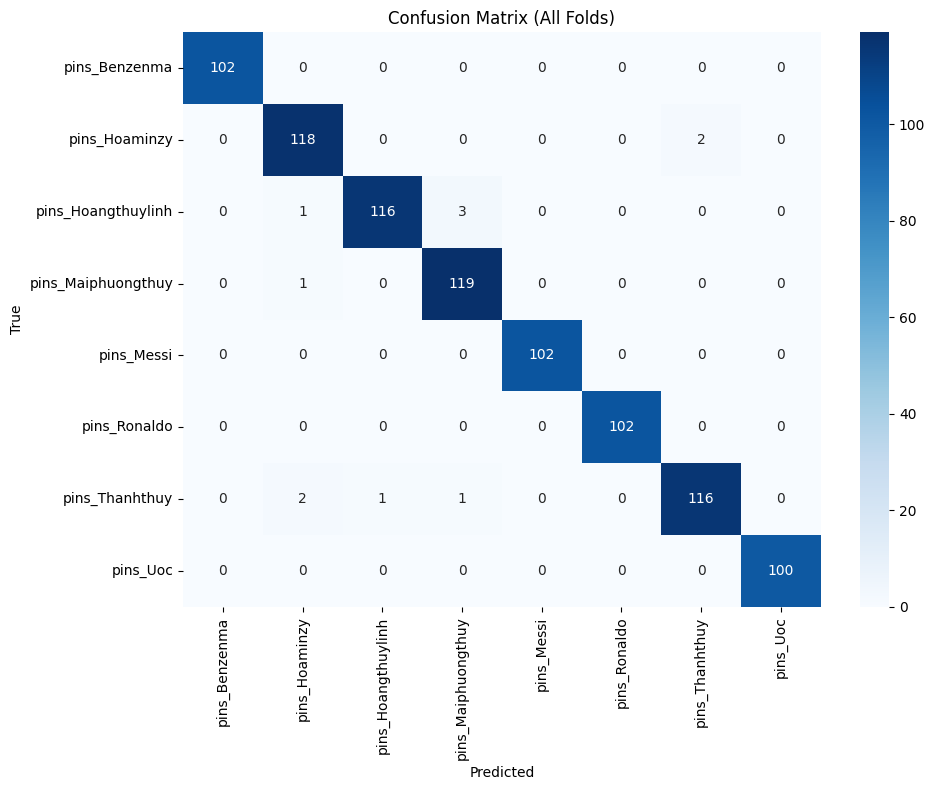

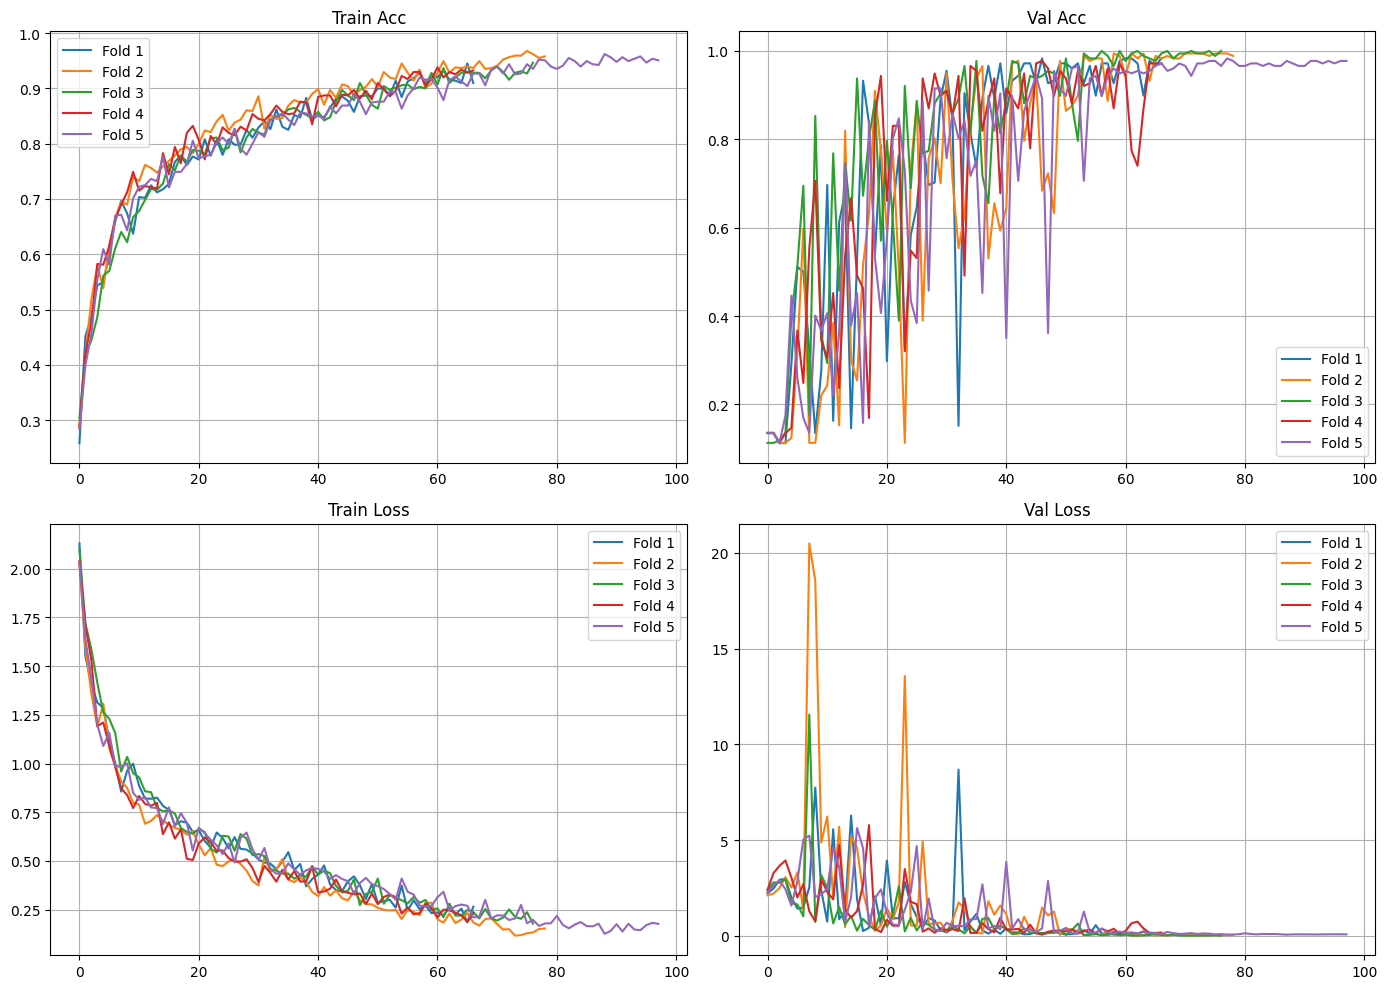


BEST MODEL: custom_cnn_fold_3.h5 (100.00%)


In [ ]:
print("\n" + "="*50)
print("K-FOLD CROSS VALIDATION RESULTS")
print("="*50)

for i, acc in enumerate(acc_per_fold):
    print(f"Fold {i+1}: {acc:.2f}%")

print(f"\nAVERAGE ACCURACY: {np.mean(acc_per_fold):.2f}% (+/- {np.std(acc_per_fold):.2f}%)")
print(f"AVERAGE LOSS: {np.mean(loss_per_fold):.4f}")

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)

class_names = list(train_gen.class_indices.keys())
print(classification_report(all_true_labels, all_predictions,
                          target_names=class_names, zero_division=0))

cm = confusion_matrix(all_true_labels, all_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (All Folds)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

if histories:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for i, history in enumerate(histories):
        axes[0, 0].plot(history.history['accuracy'], label=f'Fold {i+1}')
        axes[0, 1].plot(history.history['val_accuracy'], label=f'Fold {i+1}')
        axes[1, 0].plot(history.history['loss'], label=f'Fold {i+1}')
        axes[1, 1].plot(history.history['val_loss'], label=f'Fold {i+1}')

    for ax, title in zip(axes.flat, ['Train Acc', 'Val Acc', 'Train Loss', 'Val Loss']):
        ax.set_title(title)
        ax.legend()
        ax.grid(True)
    plt.tight_layout()
    plt.show()

best_fold = np.argmax(acc_per_fold) + 1
print(f"\nBEST MODEL: custom_cnn_fold_{best_fold}.h5 ({max(acc_per_fold):.2f}%)")

In [5]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

# Load best model
model = load_model('/content/drive/MyDrive/models/custom_cnn_fold_3.h5')

# Class names theo thứ tự alphabet
class_names = [
    'pins_Benzenma',
    'pins_Hoaminzy',
    'pins_Hoangthuylinh',
    'pins_Maiphuongthuy',
    'pins_Messi',
    'pins_Ronaldo',
    'pins_Thanhthuy',
    'pins_Uoc'
]

def predict_image(model, img_path):
    """
    Dự đoán class cho một ảnh.

    Args:
        model: Model đã load
        img_path: Đường dẫn đến ảnh cần dự đoán

    Returns:
        predicted_class: Tên class được dự đoán
        confidence: Độ tin cậy (%)
    """
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Dự đoán
    predictions = model.predict(img_array, verbose=0)
    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]
    confidence = np.max(predictions) * 100

    # In kết quả
    print(f"Predicted: {predicted_class} ({confidence:.2f}%)")
    print("-" * 40)

    # Hiển thị tất cả xác suất
    print("All probabilities:")
    for i, (name, prob) in enumerate(zip(class_names, predictions[0])):
        print(f"  {name}: {prob*100:.2f}%")

    return predicted_class, confidence

# Test với ảnh mới
predict_image(model, '/content/drive/MyDrive/AI_VGG16_Classifier/test.jpg')

Predicted: pins_Hoangthuylinh (74.09%)
----------------------------------------
All probabilities:
  pins_Benzenma: 0.06%
  pins_Hoaminzy: 1.38%
  pins_Hoangthuylinh: 74.09%
  pins_Maiphuongthuy: 0.00%
  pins_Messi: 0.00%
  pins_Ronaldo: 24.47%
  pins_Thanhthuy: 0.00%
  pins_Uoc: 0.00%


('pins_Hoangthuylinh', np.float32(74.0907))